In [1]:
import kagglehub

# Download latest version
data_path = kagglehub.dataset_download("dylanjcastillo/7k-books-with-metadata")

print("Path to dataset files:", data_path)

100%|██████████| 1.47M/1.47M [00:00<00:00, 3.91MB/s]

Extracting files...
Path to dataset files: /Users/sahelkeyvan/.cache/kagglehub/datasets/dylanjcastillo/7k-books-with-metadata/versions/3


In [1]:
import pandas as pd

data_path = '/Users/sahelkeyvan/.cache/kagglehub/datasets/dylanjcastillo/7k-books-with-metadata/versions/3'

books = pd.read_csv(f"{data_path}/books.csv")

In [2]:
books.head()

,isbn13,isbn10,title,subtitle,authors,categories,thumbnail,description,published_year,average_rating,num_pages,ratings_count
0,9780002005883,0002005883,Gilead,NaN,Marilynne Robinson,Fiction,http://books.google.com/books/content?id=KQZCP...,A NOVEL THAT READERS and critics have been eag...,2004.0,3.85,247.0,361.0
1,9780002261982,0002261987,Spider's Web,A Novel,Charles Osborne;Agatha Christie,Detective and mystery stories,http://books.google.com/books/content?id=gA5GP...,A new 'Christie for Christmas' -- a full-lengt...,2000.0,3.83,241.0,5164.0
2,9780006163831,0006163831,The One Tree,NaN,Stephen R. Donaldson,American fiction,http://books.google.com/books/content?id=OmQaw...,Volume Two of Stephen Donaldson's acclaimed se...,1982.0,3.97,479.0,172.0
3,9780006178736,0006178731,Rage of angels,NaN,Sidney Sheldon,Fiction,http://books.google.com/books/content?id=FKo2T...,"A memorable, mesmerizing heroine Jennifer -- b...",1993.0,3.93,512.0,29532.0
4,9780006280897,0006280897,The Four Loves,NaN,Clive Staples Lewis,Christian life,http://books.google.com/books/content?id=XhQ5X...,Lewis' work on the nature of love divides love...,2002.0,4.15,170.0,33684.0


In [6]:
books.isna().sum()

isbn13               0
isbn10               0
title                0
subtitle          4429
authors             72
categories          99
thumbnail          329
description        262
published_year       6
average_rating      43
num_pages           43
ratings_count       43
dtype: int64

More than half of the values in the `subtitle` column are missing. For the other columns, we need to check whether the missingness is random or if there are any dependencies or patterns

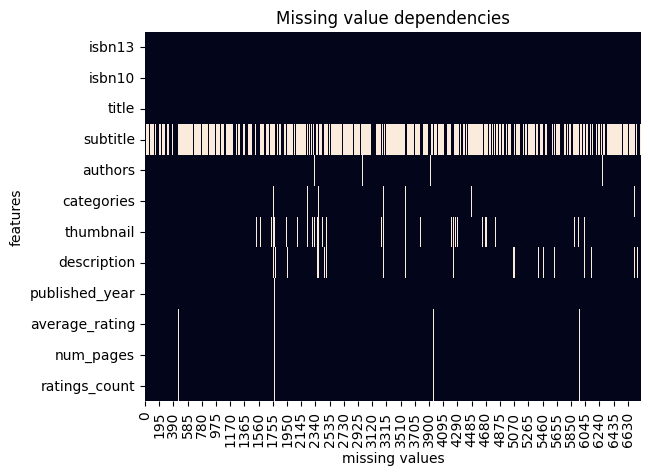

In [23]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(books.isna().transpose(), cbar=False)

plt.title('Missing value dependencies')
plt.xlabel('missing values')
plt.ylabel('features')

plt.show()

In [35]:
# Check where any of the 3 columns is missing
subset = books[['average_rating', 'num_pages', 'ratings_count']]
#any of them is missing for 1 observation
one_missing = subset.isna().any(axis=1)
#check if all is missing when one is missing
all_missing = subset[one_missing].isna().all(axis=1).mean()
print(f"Percentage of rows where all three are missing together: {all_missing:.2%}")



Percentage of rows where all three are missing together: 100.00%


It seems that there are some sorts of dependencies among the missing values in the columns `average_rating`, `num_pages` and `rating_count`. Specifically, observations that have one of these fields missing tend to have all three missing simultaneously.

This pattern suggests that the missingness is not random and may be associated with a specific characteristic of the books (e.g., unpublished, rare, or newly added books with incomplete metadata).

The next step would be to check the books where the description is missing, this is the most important column for our analysis and we need to check whether there is a bias in the type of the description which are missing. Eventually we are going to remove the missing descriptions and we must know if our recommender will be skewed towards some certain sort of books.

In [3]:
import numpy as np

books['missing_desc'] = np.where(books['description'].isna(), 1, 0)


We want to check whether missing description is related to the age of the book, number of pages or average of rating.


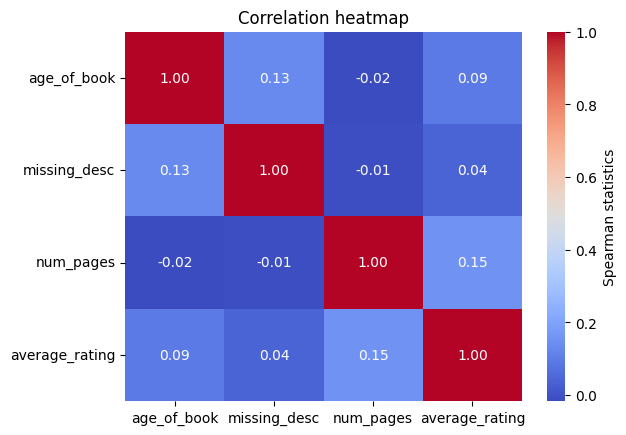

In [5]:
books['age_of_book'] = 2025 - books['published_year']

selected_cols = ['age_of_book', 'missing_desc', 'num_pages', 'average_rating']

#pearson is more appropriate for continuous values, since missing_desc is binary, spearman statistic is better for non-continuous values
corr_matrix = books[selected_cols].corr(method='spearman')

import seaborn as sns
import matplotlib.pyplot as plt

heatmap = sns.heatmap(corr_matrix, cmap='coolwarm', annot=True, fmt='.2f', cbar_kws={'label':'Spearman statistics'})

heatmap.set_title('Correlation heatmap')

plt.show()


Since we can't observe any specific pattern here for missingness, we are safe to just remove the missing instances.

In [ ]:
#remove the missing instances

missing = books[(books['description'].isna()) | (books['num_pages'].isna()) | (books['published_year'].isna())].index

data = books.drop(missing).reset_index(drop=True)

Now we move on to check the length of the description for each book. Very short descriptions are not informative and might be misleading for our recommender.

In [13]:

data['length_of_desc'] = data['description'].str.split().str.len()

We have to decide on the ideal cutoff threshold for the length of the description.

In [14]:
data.loc[data['length_of_desc'].between(0,5), 'description']

6                                             Donation.
11                                       Fantasy-roman.
75                       Nonsense rhyming story. 4 yrs+
100                      Library of Liberal Arts title.
657                    Biography of John Wesley Powell.
                             ...                       
6404                                 No Marketing Blurb
6412    Accessible and affordable illustrated biography
6429                                            Horror.
6462                        Audio Book- unabriged on CD
6494                               源氏物語54帖、「宮田切り絵」の真骨頂。
Name: description, Length: 66, dtype: object

In [16]:
pd.set_option('display.max_colwidth', 150)
data.loc[data['length_of_desc'].between(6,15), 'description']

2       Volume Two of Stephen Donaldson's acclaimed second trilogy featuing the compelling anti-hero Thomas Covenant.
37                                     Koko is Peter Straub's foray into the psychological horror of the Vietnam War.
68                                                             A matter of life and death - and the Throne of England
81                                Tie your tongue in terrible knots as you try to read aloud. Nonsense rhyming story.
82                                                  A study guide for the novel There's a Boy in the Girl's bathroom.
                                                            ...                                                      
6433                                                                   Presents two complete novels from Henry James.
6436                            Nineteen writers dig into the spaces between genres and bring up gems of new fiction.
6471                       Everything from the fingerpri

In [17]:
data.loc[data['length_of_desc'].between(16,25), 'description']

10                                         One of Sidney Sheldon's most popular and bestselling titles, repackaged and reissued for a new generation of fans.
32                                                               Tells the story of three generations of Chinese women, beginning at the turn of the century.
36                A magical and fantastic collection of early stories by one of the most original children's authors of the 20th century. For 8-11 year olds.
56                                         A young drifter finds more than he bargained for when he agrees to deliver a parcel to an English country house...
66                       A new 'The Doors of Perception' for the 21st century? A visionary journey from cynicism to shamanism by a brilliant young US writer.
                                                                                ...                                                                          
6469           Presents a collection of articles tha

We decide to remove any description with less than 25 words, as they don't seem to be informative

In [18]:
clean_data = data[data['length_of_desc'] >= 25]
clean_data.shape

(5197, 15)

In the next step we combine the values of the columns title and subtitle.
Also create a unique identifier column for each description which is goint to be used for our vector database.

In [20]:
clean_data['title_subtitle'] = (clean_data['title'] + ': ' + clean_data['subtitle'].fillna('')).str.rstrip(': ')

/var/folders/s2/0n9llbr92yqd6tcq33z2gx8m0000gn/T/ipykernel_55241/80421168.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  clean_data['title_subtitle'] = (clean_data['title'] + ': ' + clean_data['subtitle'].fillna('')).str.rstrip(': ')


In [23]:
clean_data['identifier'] = clean_data[['isbn13','description']].astype('str').agg(" ".join, axis=1)

/var/folders/s2/0n9llbr92yqd6tcq33z2gx8m0000gn/T/ipykernel_55241/1852143985.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  clean_data['identifier'] = clean_data[['isbn13','description']].astype('str').agg(" ".join, axis=1)


In [26]:
final_data = clean_data.drop(columns=['subtitle', 'age_of_book', 'missing_desc', 'length_of_desc'], axis=1)
final_data.to_csv('clean_data.csv', index=False)

In [12]:
final_data['len'] = final_data['identifier'].str.split().str.len()
max(final_data['len'])

921

In [13]:
final_data.loc[final_data['len'] > 512, 'identifier']

1497    9780345442741 1. Geneva initially has no inten...
3140    9780684813639 In this powerful, epic biography...
3176    9780687002825 Life at the end of the twentieth...
4260    9780940450660 Includes Native Son, now an HBO ...
5127    9781904271062 A. R. Humphreyswas Professor of ...
Name: identifier, dtype: object

In [4]:
import pandas as pd
import numpy as np

final_data = pd.read_csv('clean_data.csv')


In [8]:
# to conver description text into an acceptable format
from langchain_community.document_loaders import TextLoader
from langchain_text_splitters import CharacterTextSplitter
from langchain_openai import OpenAIEmbeddings
from langchain_chroma import Chroma


In [1]:
# to work with the api keys

from dotenv import load_dotenv

#calling load_dotenv, it looks at my .env file and load the keys to my current environment

load_dotenv()

True

When we query the database, what we are getting in return are the descriptions that match the one in query. In reality, we are more interested in the title and the author of the book. So we want to filter down the dataframe that contains all the books to the ones that were recommended by our recommender. However, doing this by string match is a bit messy, a nicer way would be to add isbn at the beginning of each description. In this case, when we get back the recommendations, we can easily split off the isbn from the beginning of the description and use that to filter out the results.

In [6]:
#text loader does not work with pandas df, so we need to save our identifier as a text file

final_data['identifier'].to_csv('tagged_descriptions.txt', sep = '\n', index=False, header=False)

Now, we load the documents and instantiate the text splitter

In [10]:
#loading the raw documents
raw_documents = TextLoader('tagged_descriptions.txt').load()

# splitting the text based on the new line. we dont want any overlap here as descriptions are for different books
# also we put chunk size as 0, cause in this case the splitter prioritizes to split based on our defined separator
# rather than the chunk size

text_splitter = CharacterTextSplitter(chunk_size=0, chunk_overlap=0, separator='\n')
# apply our splitter to the documents

documents = text_splitter.split_documents(raw_documents)

Created a chunk of size 1168, which is longer than the specified 0
Created a chunk of size 1214, which is longer than the specified 0
Created a chunk of size 373, which is longer than the specified 0
Created a chunk of size 309, which is longer than the specified 0
Created a chunk of size 483, which is longer than the specified 0
Created a chunk of size 482, which is longer than the specified 0
Created a chunk of size 960, which is longer than the specified 0
Created a chunk of size 188, which is longer than the specified 0
Created a chunk of size 843, which is longer than the specified 0
Created a chunk of size 296, which is longer than the specified 0
Created a chunk of size 197, which is longer than the specified 0
Created a chunk of size 881, which is longer than the specified 0
Created a chunk of size 1088, which is longer than the specified 0
Created a chunk of size 1189, which is longer than the specified 0
Created a chunk of size 304, which is longer than the specified 0
Create

In [ ]:
#creating a vector database from embeddings
db_books = Chroma.from_documents(
    documents,
    embedding= OpenAIEmbeddings()
)

In [ ]:
#example
query = 'a book about children and nature'

docs = db_books.similarity_search(query, k=10)

final_data[final_data['isbn13'] == int(docs[0].page_content.split()[0].strip())]

,isbn13,isbn10,title,authors,categories,thumbnail,description,published_year,average_rating,num_pages,ratings_count,title_subtitle,identifier,len
3747,9780786808069,0786808063,Baby Einstein: Neighborhood Animals,Marilyn Singer;Julie Aigner-Clark,Juvenile Fiction,http://books.google.com/books/content?id=X9a4P...,Children will discover the exciting world of t...,2001.0,3.89,16.0,180.0,Baby Einstein: Neighborhood Animals,9780786808069 Children will discover the excit...,41


In [21]:
def retrieve_books(query:str, top_k:int = 10) -> pd.DataFrame:
    results = db_books.similarity_search(query, k=50)

    book_list = []
    for i in range(len(results)):
        book_list.append(int(results[i].page_content.split()[0].strip('"')))

    return final_data[final_data['isbn13'].isin(book_list)].head(top_k)

In [22]:
retrieve_books('a book to teach children about nature')

,isbn13,isbn10,title,authors,categories,thumbnail,description,published_year,average_rating,num_pages,ratings_count,title_subtitle,identifier,len
31,9780007105045,0007105045,Tree and Leaf,John Ronald Reuel Tolkien,Literary Collections,http://books.google.com/books/content?id=aPb_A...,"""The two works 'On fairy-stories' and 'Leaf by...",2001.0,4.09,176.0,2245.0,Tree and Leaf: The Homecoming of Beorhtnoth : ...,"9780007105045 ""The two works 'On fairy-stories...",39
59,9780007151240,0007151241,The Family Way,Tony Parsons,Parenthood,http://books.google.com/books/content?id=dJEIx...,It should be the most natural thing in the wor...,2005.0,3.51,400.0,2095.0,The Family Way,9780007151240 It should be the most natural th...,30
324,9780060959036,0060959037,Prodigal Summer,Barbara Kingsolver,Fiction,http://books.google.com/books/content?id=06IwG...,Barbara Kingsolver's fifth novel is a hymn to ...,2001.0,4.00,444.0,85440.0,Prodigal Summer: A Novel,9780060959036 Barbara Kingsolver's fifth novel...,77
400,9780062700254,0062700251,Bulfinch's Mythology,Richard P. Martin,Reference,http://books.google.com/books/content?id=eev4u...,A beautiful gift edition of Thomas Bulfinch's ...,1991.0,4.10,768.0,64.0,"Bulfinch's Mythology: The Age of the Fable, Th...",9780062700254 A beautiful gift edition of Thom...,26
429,9780064434980,0064434982,The Deer in the Wood,Laura Ingalls Wilder,Juvenile Fiction,http://books.google.com/books/content?id=V7YDW...,Even the youngest child can enjoy a special ad...,1999.0,4.17,32.0,302.0,The Deer in the Wood,9780064434980 Even the youngest child can enjo...,40
442,9780067575208,006757520X,The Sense of Wonder,Rachel Carson,Nature,http://books.google.com/books/content?id=Zee5S...,"First published more than three decades ago, t...",1998.0,4.39,112.0,1160.0,The Sense of Wonder,9780067575208 First published more than three ...,323
692,9780140448009,0140448004,Three Tales,Gustave Flaubert;Roger Whitehouse;Geoffrey Wall,Fiction,http://books.google.com/books/content?id=XFzga...,Features short fiction by the French naturalis...,2005.0,3.71,110.0,3050.0,Three Tales,9780140448009 Features short fiction by the Fr...,34
707,9780140568196,0140568190,The Giraffe and the Pelly and Me,Roald Dahl;Quentin Blake,Candy,http://books.google.com/books/content?id=J7FdI...,"A Dahl story in which the giraffe, the pelican...",2001.0,3.81,32.0,16265.0,The Giraffe and the Pelly and Me,9780140568196 A Dahl story in which the giraff...,26
711,9780140621624,0140621628,The Railway Children,E. Nesbit,Fiction,http://books.google.com/books/content?id=fFesd...,"When their father is sent away to prison, thre...",1995.0,4.00,212.0,178.0,The Railway Children,9780140621624 When their father is sent away t...,38
763,9780141186078,0141186070,The Log from the Sea of Cortez,John Steinbeck,Biography & Autobiography,http://books.google.com/books/content?id=9CrIf...,This light-hearted journal tells of John Stein...,2001.0,3.84,288.0,3226.0,The Log from the Sea of Cortez,9780141186078 This light-hearted journal tells...,29


In [19]:
cat_count = books['categories'].value_counts()

top_categories = cat_count[cat_count > 30]

top_categories

categories
Fiction                        2588
Juvenile Fiction                538
Biography & Autobiography       401
History                         264
Literary Criticism              166
Philosophy                      160
Comics & Graphic Novels         159
Religion                        137
Drama                           132
Juvenile Nonfiction             116
Poetry                           79
Science                          71
Literary Collections             71
Business & Economics             67
Social Science                   60
Performing Arts                  50
Cooking                          47
Art                              46
Body, Mind & Spirit              44
Travel                           43
Psychology                       43
Computers                        42
Self-Help                        38
Political Science                36
Family & Relationships           34
Language Arts & Disciplines      33
Humor                            32
Health & Fitness 